<a href="https://colab.research.google.com/github/durvankuringale051/ml-predictive-maintenance-pipeline/blob/main/LinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

In [ ]:
df = pd.read_csv('01_linear_regression.csv')
df.columns

Index(['feature', 'target'], dtype='object')

In [ ]:
print(f'shape : {df.shape}')

shape : (1500, 2)


In [ ]:
X = df['feature'].values
y = df['target'].values

Data Splitting

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,shuffle=False)

In [ ]:
X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,dtype=torch.float32)

In [ ]:
X_train_tensor.shape
X_test_tensor.shape

torch.Size([300])

In [ ]:
class CustomDataset(Dataset):

  def __init__(self,features,labels):

    self.features = features
    self.labels = labels

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self, index):
    #tranformation
    return self.features[index] , self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train_tensor,y_train_tensor)
test_dataset = CustomDataset(X_test_tensor,y_test_tensor)


In [ ]:
train_dataloader = DataLoader(train_dataset,batch_size=10,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=10,shuffle=False)

In [ ]:
for fea , tar in train_dataloader:
  print(f'Feature : {fea}')
  print(f'Target : {tar}')

Feature : tensor([-2.5092,  9.0143,  4.6399,  1.9732, -6.8796, -6.8801, -8.8383,  7.3235,
         2.0223,  4.1615])
Target : tensor([ -6.7810,  43.1319,  20.4604,  10.6153, -15.0336, -12.2009, -21.1656,
         33.7601,  15.2676,  23.2719])
Feature : tensor([-9.5883,  9.3982,  6.6489, -5.7532, -6.3635, -6.3319, -3.9152,  0.4951,
        -1.3611, -4.1754])
Target : tensor([-25.0412,  40.4561,  30.4794, -13.2614, -16.7802, -15.7230, -10.0890,
          8.5363,   0.2590,  -9.8211])
Feature : tensor([ 2.2371, -7.2101, -4.1571, -2.6728, -0.8786,  5.7035, -6.0065,  0.2847,
         1.8483, -9.0710])
Target : tensor([ 15.1895, -15.4514,  -5.7132,  -5.4957,   1.9456,  28.8439, -15.9878,
          7.5471,  14.5691, -26.6852])
Feature : tensor([ 2.1509, -6.5895, -8.6990,  8.9777,  9.3126,  6.1679, -3.9077, -8.0466,
         3.6847, -1.1970])
Target : tensor([ 14.7389, -18.7314, -24.6491,  39.0616,  36.4083,  29.4688,  -6.7163,
        -20.0580,  20.3441,   5.5390])
Feature : tensor([-7.5592, -

creating neural network

In [ ]:
class Model(nn.Module):

  def __init__(self,num_features):

    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(num_features,1),
    )

  def forward(self,features):
    out = self.network(features)
    return out



parameters

In [ ]:
learning_rate = 0.01
epochs = 1000

In [ ]:
loss_function = nn.MSELoss()

In [ ]:
X_test_tensor - X_test_tensor.to(torch.float32)

X_test_tensor.dtype

torch.float32

using network

In [ ]:
model = Model(num_features=1)

optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

pred_vals = []

for epoch in range(epochs):

  for batch_feature , batch_target in train_dataloader:

    # print(f'Feature : {batch_feature} | size : {batch_target.shape}')
    # print(f'Target : {batch_target} Shape : {batch_target.shape}')


    y_pred = model(batch_feature.reshape(-1,1))
    loss = loss_function(y_pred,batch_target.view(-1,1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
          print(
              f"Epoch: {epoch}, "
              f"Loss: {loss.item():.4f}, "
              f"Weight: {model.network[0].weight.item():.4f}, "
              f"Bias: {model.network[0].bias.item():.4f}"
          )



Epoch: 0, Loss: 755.8236, Weight: 2.3085, Bias: 0.2083
Epoch: 0, Loss: 64.7185, Weight: 2.9750, Bias: 0.2788
Epoch: 0, Loss: 42.0164, Weight: 3.0061, Bias: 0.3893
Epoch: 0, Loss: 56.6730, Weight: 3.4488, Bias: 0.5212
Epoch: 0, Loss: 41.7516, Weight: 3.2015, Bias: 0.6466
Epoch: 0, Loss: 55.3321, Weight: 3.7078, Bias: 0.7831
Epoch: 0, Loss: 50.9067, Weight: 3.5482, Bias: 0.9218
Epoch: 0, Loss: 55.8540, Weight: 3.5036, Bias: 1.0631
Epoch: 0, Loss: 23.3108, Weight: 3.6196, Bias: 1.1574
Epoch: 0, Loss: 42.3224, Weight: 3.4553, Bias: 1.2802
Epoch: 0, Loss: 30.8165, Weight: 3.2450, Bias: 1.3870
Epoch: 0, Loss: 53.5760, Weight: 3.6759, Bias: 1.5276
Epoch: 0, Loss: 25.6293, Weight: 3.5256, Bias: 1.6170
Epoch: 0, Loss: 43.0495, Weight: 3.4343, Bias: 1.7444
Epoch: 0, Loss: 28.8092, Weight: 3.1657, Bias: 1.8487
Epoch: 0, Loss: 32.9031, Weight: 3.4440, Bias: 1.9543
Epoch: 0, Loss: 22.3830, Weight: 3.3364, Bias: 2.0431
Epoch: 0, Loss: 30.4598, Weight: 3.2552, Bias: 2.1491
Epoch: 0, Loss: 27.5000, We

In [ ]:
model.eval()

Model(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
  )
)

In [ ]:


pred_vals = []
with torch.no_grad():

  for test_feature , test_target in test_dataloader:
    y_pred_test = model(test_feature.reshape(-1,1))
    for i in y_pred_test.tolist():

      pred_vals.append(i[0])
test_loss = loss_function(y_pred_test,test_feature.reshape(-1,1))
print("Test MSE:", test_loss.item())

print("Weight:", model.network[0].weight.item())
print("Bias:", model.network[0].bias.item())

Test MSE: 137.42507934570312
Weight: 3.3555264472961426
Bias: 7.041493892669678


In [ ]:
pred_vals

[24.373674392700195,
 -24.86372947692871,
 -25.0290470123291,
 -4.796117305755615,
 6.279332160949707,
 25.188678741455078,
 19.342544555664062,
 3.4109957218170166,
 -8.150541305541992,
 40.403778076171875,
 2.08748197555542,
 3.7790513038635254,
 -15.532890319824219,
 26.826318740844727,
 20.039609909057617,
 -11.697803497314453,
 -20.98513412475586,
 19.154897689819336,
 17.410823822021484,
 -8.175180435180664,
 37.29918670654297,
 -16.376195907592773,
 2.500446319580078,
 36.81279373168945,
 1.6543517112731934,
 16.338043212890625,
 0.16899919509887695,
 -8.111043930053711,
 39.521488189697266,
 0.9568510055541992,
 33.48970031738281,
 -11.081396102905273,
 -12.212200164794922,
 -24.424345016479492,
 17.219934463500977,
 -1.7817730903625488,
 31.493770599365234,
 5.24359655380249,
 38.46220397949219,
 -14.063055038452148,
 31.77998924255371,
 25.604055404663086,
 25.223203659057617,
 30.18008041381836,
 24.55895233154297,
 15.51220703125,
 -17.705856323242188,
 -24.330923080444336,

In [ ]:
y_pred_test.shape

torch.Size([10, 1])

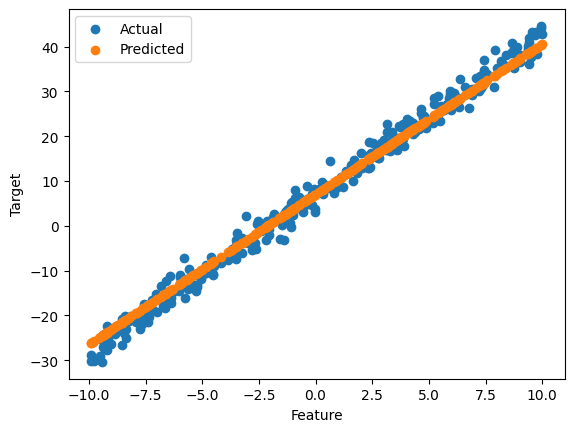

In [ ]:
import numpy as np
plt.scatter(
    X_test_tensor.numpy(),
    y_test_tensor.numpy(),
    label="Actual"
)

plt.scatter(
    X_test_tensor.numpy(),
    np.array(pred_vals),
    label="Predicted"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()